<a href="https://colab.research.google.com/github/guilhermek32/ListaVisao-2026.1/blob/main/Vis%C3%A3o_Lista_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dupla: Antonio Guilherme da Silva e Jean Patrick Martins Almeida

In [ ]:
import numpy as np
import math

In [ ]:
def generate_banded_gray_ppm(filename, width, height, num_bands):
    shades = np.linspace(0, 255, num_bands, dtype=np.uint8)

    band_width = width // num_bands

    row = np.repeat(shades, band_width)

    if len(row) < width:
        row = np.pad(row, (0, width - len(row)), mode='edge')

    image_2d = np.tile(row, (height, 1))
    image_rgb = np.stack((image_2d,) * 3, axis=-1)

    with open(filename, 'wb') as f:
        f.write(f"P6\n{width} {height}\n255\n".encode('ascii'))
        f.write(image_rgb.tobytes())

generate_banded_gray_ppm('banded_gray.ppm', 256, 256, 8)

1. Pesquise sobre o formato de imagens PPM. Em seguida, implemente uma função que receba uma imagem em formato PPM, o tamanho n de um filtro espacial com dimensções n × n e a matriz com os pesos do filtro, e converta para um NumPy array. Em seguida, ela deve aplicar o filtro como uma convolução, gerando e salvando (opcionalmente) a imagem resultante no disco em formato PPM. Você não pode usar a OpenCV em nenhum desses passos. As especificações do formato PPM podem ser encontradas aqui: https://netpbm.sourceforge.net/doc/ppm.html

In [ ]:
def f(file_name, n, filter_array):
    with open(file_name, 'rb') as file:
        magic_number = file.readline().decode().strip()

        header_values = []
        while len(header_values) < 3:
            line = file.readline().decode()
            if '#' in line:
                line = line.split('#')[0]
            header_values.extend(line.split())

        w, h, maxval = int(header_values[0]), int(header_values[1]), int(header_values[2])

        img = np.fromfile(file, dtype=np.uint8).reshape((h, w, 3))

    pad_size = n // 2

    padded_img = np.pad(img, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='edge')
    output_img = np.zeros_like(img, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            for c in range(3):
                region = padded_img[i:i+n, j:j+n, c]
                output_img[i, j, c] = np.sum(region * filter_array)

    output_img = np.clip(output_img, 0, 255).astype(np.uint8)

    output_name = file_name.replace('.ppm', '_filtered.ppm')
    with open(output_name, 'wb') as file:
        file.write(f"P6\n{w} {h}\n255\n".encode())
        file.write(output_img.tobytes())

    return output_img

In [ ]:
file_name = 'banded_gray.ppm'
n = 3

# Kernels
filter_blur = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

# Sharpening filter
filter_sharp_strong = np.array([
    [-1, -1, -1],
    [-1, 9, -1],
    [-1, -1, -1]
])

filter_sharp_standard = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

filter_image = f(file_name, n, filter_blur)

print("Verifique o arquivo '_filtered.ppm'")

Verifique o arquivo '_filtered.ppm'


Segunda Questão

Considere a função Gaussiana bidimensional definida por: $G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$ ,
onde σ representa o desvio padrão da distribuição. Um filtro Gaussiano discreto pode ser obtido amostrando a função Gaussiana contínua em uma grade bidimensional centrada na origem. Seja k o tamanho do filtro Gaussiano desejado, assumindo que k é um número ímpar (por exemplo, 3, 5, 7, etc.). O filtro terá dimensões k × k e será centrado na posição (0, 0). O procedimento para gerar a máscara do filtro é o seguinte:

1. Considere uma grade de coordenadas (x, y) tal que x, y ∈  −k − 1 2 , . . . , 0, . . . , k − 1 / 2  .

2. Para cada posição (x, y) da grade, calcule o valor da função Gaussiana G(x, y).

3. Armazene os valores calculados em uma matriz H de dimensão k × k, formando a máscara do filtro.

4. Normalize a máscara dividindo todos os seus elementos pela soma total dos valores da matriz, garantindo que X i X j H[i, j] = 1

In [ ]:
import numpy as np
import math

def gerar_filtro_gaussiano(k, sigma):
    if k % 2 == 0:
        raise ValueError("O valor de k deve ser um número ímpar.")

    # Passo 3 (preparação): Criar a matriz H vazia de dimensão k x k
    H = np.zeros((k, k), dtype=np.float32)

    # Passo 1: Definir o limite da grade de coordenadas
    # Isso corresponde a (k - 1) / 2
    limite = (k - 1) // 2

    soma_total = 0.0

    # Passo 2: Para cada posição (x, y) da grade, calcule G(x, y)
    for i in range(k):
        for j in range(k):
            # Mapeando os índices da matriz (i, j) para o plano cartesiano (x, y)
            # A origem (0,0) ficará no centro da matriz
            x = j - limite
            y = i - limite

            # Calculando o valor da função Gaussiana G(x, y)
            termo1 = 1 / (2 * math.pi * (sigma ** 2))
            termo2 = math.exp(-(x**2 + y**2) / (2 * (sigma ** 2)))
            G_xy = termo1 * termo2

            # Passo 3: Armazenar os valores na matriz H
            H[i, j] = G_xy

            # Acumulando a soma para o próximo passo
            soma_total += G_xy

    # Passo 4: Normalize a máscara dividindo todos os elementos pela soma total
    # Isso garante que a soma de todos os elementos seja 1
    for i in range(k):
        for j in range(k):
            H[i, j] = H[i, j] / soma_total

    return H

3.
Usando as funções da questão 1 e 2, escolha uma imagem em tom
de cinza e experimente suavizá-la com filtros gaussianos, considerando todas
as combinações de 3 variações de valores k e σ (totalizando 9 combinações).
Dica: experimente começar calibrando σ ≈
k /
6
.


<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9484/2649839734.py:29: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"k = {k} | $\sigma$ = {sigma}")


Iniciando o processamento das 9 convoluções. Isso pode levar alguns segundos...


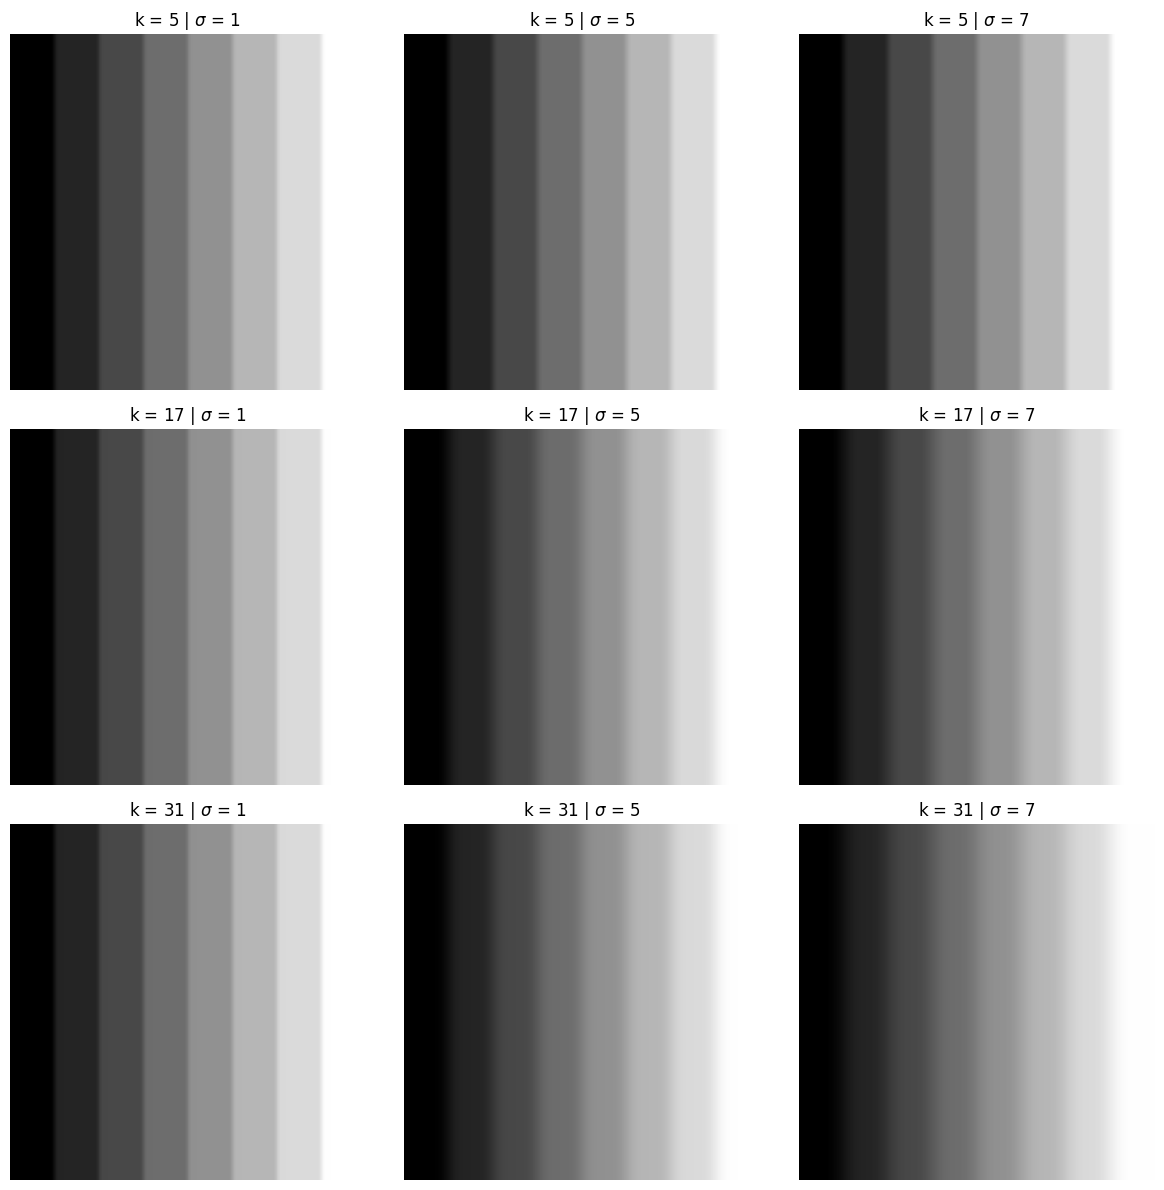

In [ ]:
import matplotlib.pyplot as plt

# Arquivo base gerado na etapa anterior
file_name = 'banded_gray_filtered.ppm'

# 1. Definição das 3 variações de k (devem ser ímpares) e 3 variações de sigma
k_valores = [5, 17, 31]
sigma_valores = [1, 5, 7]

# Configura uma figura com um grid 3x3 para plotar as 9 imagens
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

print("Iniciando o processamento das 9 convoluções. Isso pode levar alguns segundos...")

# 2. Loop para testar todas as 9 combinações
for i, k in enumerate(k_valores):
    for j, sigma in enumerate(sigma_valores):

        # A. Gera a máscara gaussiana para a combinação atual (Sua Questão 2)
        filtro_atual = gerar_filtro_gaussiano(k, sigma)

        # B. Aplica a convolução (Sua Questão 1)
        # Capturamos o array retornado para exibi-lo no grid
        imagem_filtrada = f(file_name, k, filtro_atual)

        # C. Exibe a imagem na posição correta do grid (linha i, coluna j)
        ax = axes[i, j]
        ax.imshow(imagem_filtrada)
        ax.set_title(f"k = {k} | $\sigma$ = {sigma}")
        ax.axis('off') # Esconde os eixos numéricos para o visual ficar limpo

plt.tight_layout()
plt.show()

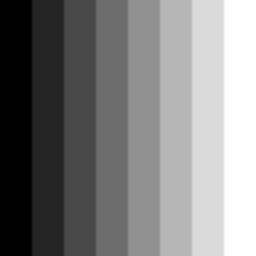

In [ ]:
from PIL import Image
from IPython.display import display

imagem = Image.open('banded_gray_filtered.ppm')

display(imagem)

Quarta questão

Utilize a função implementada nas questões anteriores para realizar
o seguinte experimento:

1. Utilize a mesma imagem em tons de cinza escolhida na questão 3.

2. Construa filtros passa-alta utilizando os filtros passa-baixa com diferentes combinações de parâmetros k e σ.

3. Aplique esses filtros à imagem e exiba os resultados, lado a lado com a
imagem original.

<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9484/1480962705.py:50: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Alta k={k} | $\sigma$={sigma}")


Construindo e aplicando os filtros passa-alta. Aguarde...


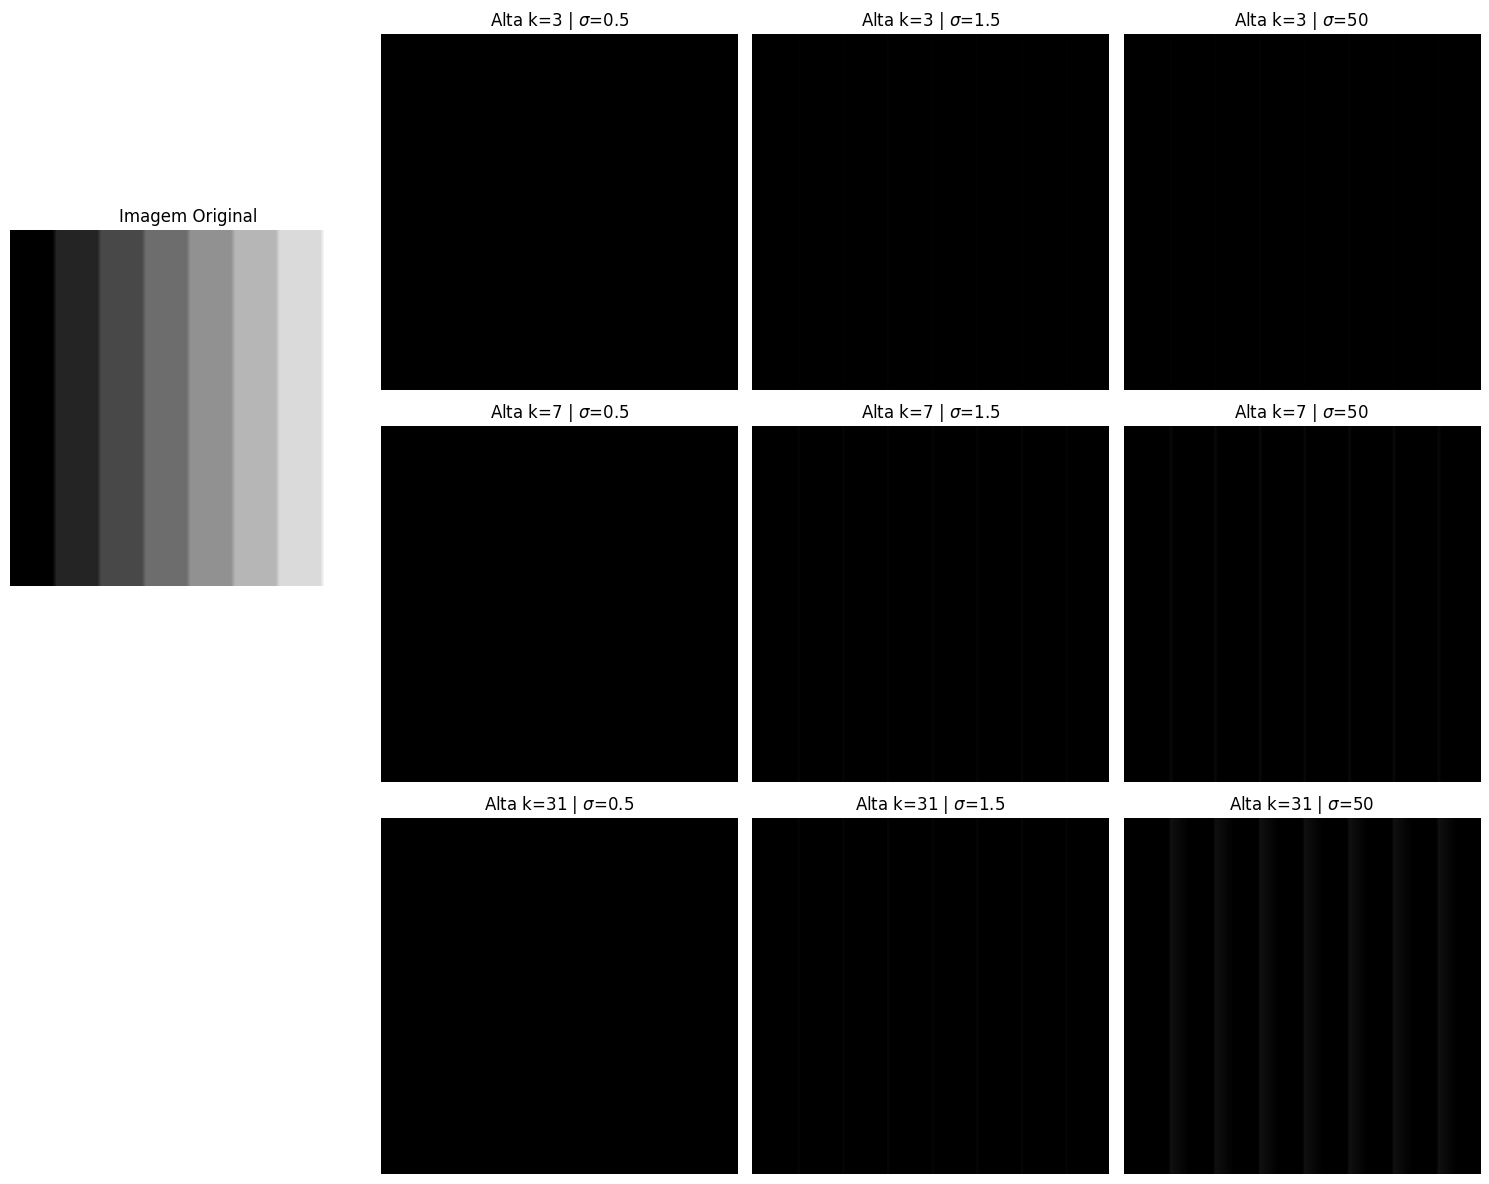

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# A mesma imagem em tons de cinza escolhida na questão 3
file_name = 'banded_gray_filtered.ppm'

# Variações solicitadas
k_valores = [3, 7, 31]
sigma_valores = [0.5, 1.5, 50]

# Configura uma figura grande: 1 espaço para a original + grid 3x3 para os filtros
fig = plt.figure(figsize=(15, 12))

print("Construindo e aplicando os filtros passa-alta. Aguarde...")

# 1. Plotar a Imagem Original primeiro para comparação
ax_orig = fig.add_subplot(3, 4, (1, 5)) # Ocupa a primeira coluna
img_original = plt.imread(file_name) # Lendo a original para exibição
ax_orig.imshow(img_original)
ax_orig.set_title("Imagem Original")
ax_orig.axis('off')

# 2. Loop para testar as 9 combinações
plot_index = 2

for i, k in enumerate(k_valores):
    for j, sigma in enumerate(sigma_valores):

        # A. Gera o filtro passa-baixa (Gaussiano)
        filtro_passa_baixa = gerar_filtro_gaussiano(k, sigma)

        # B. Constrói o filtro Identidade do mesmo tamanho
        filtro_identidade = np.zeros((k, k), dtype=np.float32)
        filtro_identidade[k//2, k//2] = 1.0

        # C. Constrói o filtro Passa-Alta
        filtro_passa_alta = filtro_identidade - filtro_passa_baixa

        # D. Aplica o filtro passa-alta usando sua função da Questão 1
        imagem_filtrada = f(file_name, k, filtro_passa_alta)

        # Ajuste do índice do subplot para pular a coluna da imagem original
        if plot_index % 4 == 1:
            plot_index += 1

        ax = fig.add_subplot(3, 4, plot_index)
        # Exibe a imagem. Como destacamos bordas, os valores podem ser muito baixos.
        # Usamos cmap='gray' e forçamos a exibição dos detalhes.
        ax.imshow(imagem_filtrada, cmap='gray')
        ax.set_title(f"Alta k={k} | $\sigma$={sigma}")
        ax.axis('off')

        plot_index += 1

plt.tight_layout()
plt.show()

5. Analise visualmente os resultados das questões 3 e 4 e discuta: 1. Como o aumento do tamanho do filtro k afeta os resultados em cada questão; 2. Como o valor de σ afeta os resultados em cada questão.

Resposta: